# Decission tree

# 1 Importar librerias

In [3]:
import os
import requests
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, export_text
from pickle import dump
from sklearn.tree import plot_tree

# 2. Abrir csv

In [4]:
df = pd.read_csv("/workspaces/steven10015-intro-ml/data/raw/diabetes.csv")
# Fijar el id como indice
pd.set_option('display.max_columns', None)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# 3. Cribado manual

## 3.1 Columnas con valores únicos

In [5]:
unicos = df.nunique()
df[unicos[unicos == 1].index]

""
0
1
2
3
4
...
763
764
765
766


## 3.2 Visualizar valores duplicados

### Filas

In [6]:
filas_dupli = df.duplicated()
df[filas_dupli]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


### Columnas

In [7]:
dup_col=df.T.duplicated(keep=False).sum()
print("No hay variables exactamente iguales" if dup_col==0 else "Hay variables exactamente iguales")

No hay variables exactamente iguales


## 3.3 Valores 0 a NaN

In [8]:
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

## 3.4 Datos faltantes

In [9]:
missing=df.isna().mean()*100
missing[missing>0]

Glucose           0.651042
BloodPressure     4.557292
SkinThickness    29.557292
Insulin          48.697917
BMI               1.432292
dtype: float64

In [10]:
missing_per_row = df.isna().sum(axis=1)
(missing_per_row >= 3).sum()

np.int64(35)

In [11]:
df = df[missing_per_row < 3] # Se eliminan los anteriores 

Dado que la eliminación indiscriminada de filas puede resultar demasiado agresiva, se optó por eliminar únicamente aquellas observaciones que contenían tres o más valores faltantes, ya que su nivel de incompletitud dificulta una imputación fiable.

In [12]:
fila_datos_faltantes = df.isna().any(axis=1).sum() # any sirve para ver CUALQUIER dato faltante
fila_datos_faltantes[fila_datos_faltantes>0]

array([341])

<Axes: >

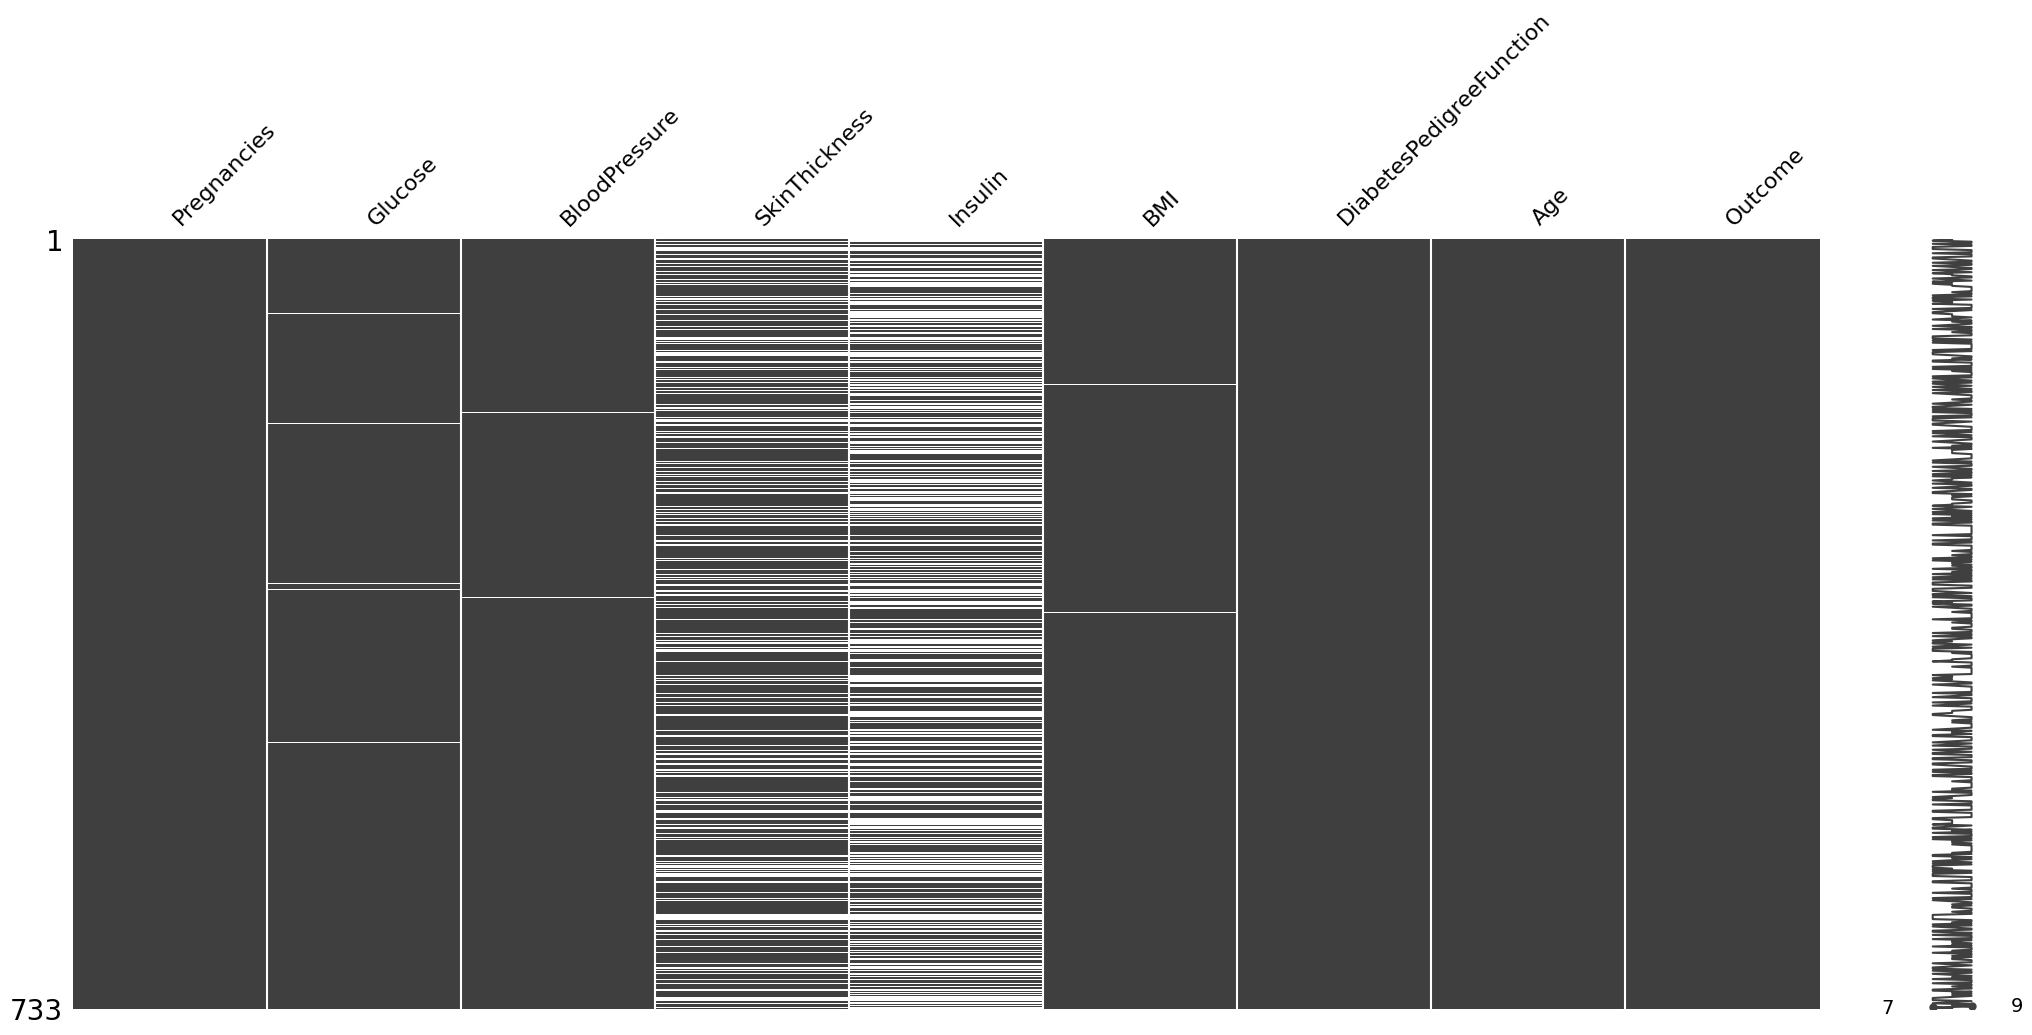

In [13]:
msno.matrix(df)

## 4. División train/test

In [14]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Outliers

In [15]:
# 1. Lista de columnas (aseguramos que el orden sea consistente)
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
X_train[columns].describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,586.000000,585.000000,585.000000,433.000000,322.000000,584.000000,586.000000,586.000000
mean,3.863481,121.755556,72.218803,29.027714,154.652174,32.295890,0.477916,33.121160
std,3.365760,30.614652,12.394486,10.779961,121.442537,6.760838,0.333171,11.606099
min,0.000000,44.000000,24.000000,7.000000,16.000000,18.200000,0.078000,21.000000
25%,1.000000,100.000000,64.000000,21.000000,76.000000,27.400000,0.248000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,121.000000,31.950000,0.379000,29.000000
75%,6.000000,142.000000,80.000000,37.000000,184.250000,36.425000,0.643750,40.750000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.329000,81.000000


## 5.1 Graficar

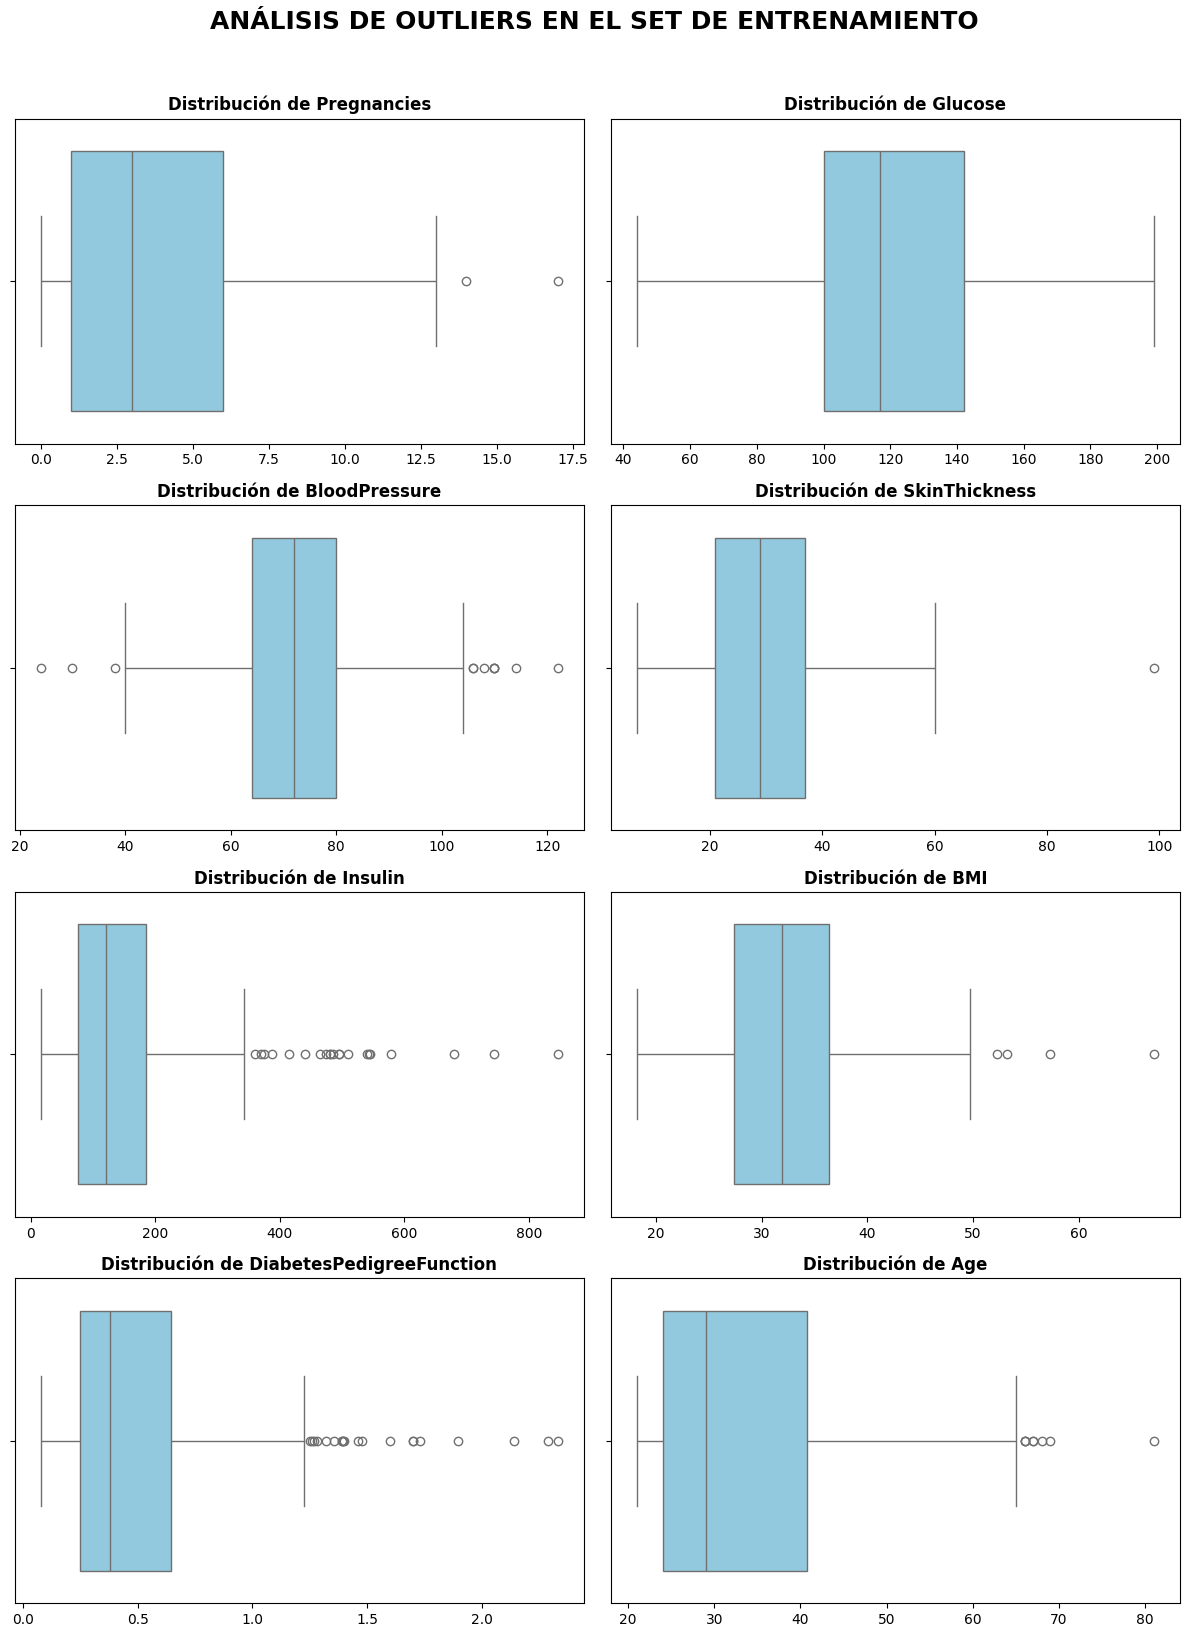

In [16]:

# 2. Configuración de la figura (4 filas x 2 columnas)
fig, axis = plt.subplots(4, 2, figsize=(12, 16))

# 3. Rellenar los boxplots de forma automática para evitar errores manuales
# Usamos un flatten() para recorrer los ejes fácilmente del 0 al 7
for i, col in enumerate(columns):
    row = i // 2
    col_idx = i % 2
    
    sns.boxplot(ax=axis[row, col_idx], data=X_train, x=col, color="skyblue")
    axis[row, col_idx].set_title(f"Distribución de {col}", fontsize=12, fontweight="bold")
    axis[row, col_idx].set_xlabel("") # Limpiamos el label para que no se vea amontonado

# 4. Ajustes finales de estilo
fig.suptitle("ANÁLISIS DE OUTLIERS EN EL SET DE ENTRENAMIENTO", size=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Distribuciones Asimétricas a la Derecha (Right-Skewed):
Variables como Insulin, DiabetesPedigreeFunction, BMI y Age presentan distribuciones asimétricas a la derecha, donde la mayoría de las observaciones se concentran en valores bajos o moderados, con una cola larga hacia valores altos. Esto indica que los valores elevados son poco frecuentes, pero clínicamente plausibles, especialmente en variables relacionadas con la diabetes.

Distribuciones Cercanas a la Normal:
Características como Glucose y BloodPressure, una vez ignorados los valores cero no válidos, muestran distribuciones más cercanas a una forma normal. Estas variables se agrupan alrededor de un valor central fisiológicamente razonable, con una dispersión relativamente equilibrada y menos valores extremos que en variables altamente sesgadas.

Outliers:
Todos los diagramas de caja evidencian la presencia de valores atípicos, siendo más notorios en Insulin, DiabetesPedigreeFunction, Pregnancies y Age. No obstante, la mayoría de estos outliers representan valores reales y coherentes con el contexto clínico, reflejando la variabilidad natural de la población analizada.

Valores Cero:
Varias variables, en particular Glucose, BloodPressure, SkinThickness, Insulin y BMI, contienen valores iguales a cero que no son fisiológicamente posibles. Estos ceros probablemente corresponden a datos faltantes o errores de registro, por lo que deberían tratarse como valores perdidos durante el preprocesamiento.

Distribución de la Edad:
La variable Age está sesgada hacia individuos más jóvenes, con la mayoría de los registros entre 20 y 40 años, lo que indica una población predominantemente joven. La menor representación de personas de mayor edad puede influir en el análisis y debe tenerse en cuenta al interpretar los resultados del modelo.

# 6. Imputar

In [17]:
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# 7. Escalar

In [18]:
scaler = StandardScaler()
X_train_final = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train.columns)
X_test_final = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test.columns)

## 8. Selección de características

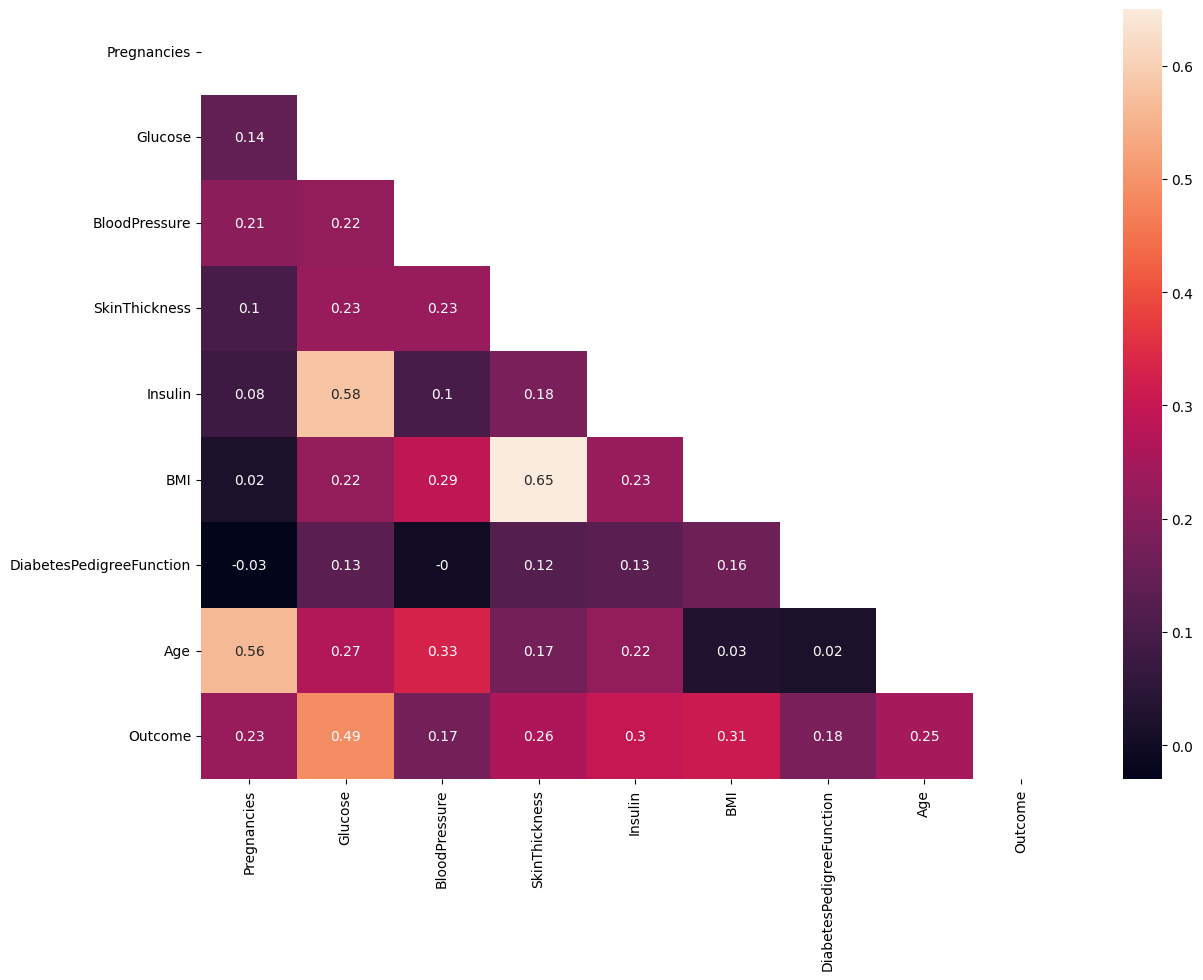

In [19]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr().round(2), annot=True, mask=np.triu(df.corr()))
plt.show()

El mapa de calor muestra las correlaciones lineales entre las variables del dataset de diabetes, permitiendo identificar relaciones relevantes entre los predictores y la variable objetivo (Outcome), así como posibles dependencias entre variables explicativas.

En primer lugar, Glucose presenta la mayor correlación positiva con Outcome (≈ 0.49), lo que indica que los niveles de glucosa son el factor más fuertemente asociado con la presencia de diabetes en el conjunto de datos. Este resultado es coherente desde el punto de vista clínico y valida la relevancia de esta variable para el modelado predictivo.

Otras variables que muestran una correlación moderada con Outcome son BMI (≈ 0.31), Insulin (≈ 0.30), Age (≈ 0.25) y Pregnancies (≈ 0.23). Estas asociaciones sugieren que factores relacionados con la obesidad, la resistencia a la insulina, la edad y el historial reproductivo influyen de manera significativa, aunque no determinante, en el diagnóstico de diabetes.

La variable DiabetesPedigreeFunction presenta una correlación positiva más débil con Outcome (≈ 0.18), lo que indica que el componente hereditario tiene cierta influencia, aunque menor en comparación con otras variables clínicas.

En cuanto a las relaciones entre variables independientes, destacan correlaciones moderadas como:

BMI y SkinThickness (≈ 0.65), lo cual es esperable, ya que ambas están relacionadas con la composición corporal.

Insulin y Glucose (≈ 0.58), reflejando la relación fisiológica entre los niveles de glucosa en sangre y la respuesta insulínica.

Age y Pregnancies (≈ 0.56), una relación lógica debido al mayor número de embarazos acumulados con el aumento de la edad.

Por otro lado, variables como BloodPressure y DiabetesPedigreeFunction muestran correlaciones bajas con la mayoría de las demás variables, lo que sugiere que aportan información relativamente independiente al modelo.

In [20]:
# 1. Identificar columnas
continuos_f = list(df.select_dtypes('float64').columns)

# 2. Definir la función de limpieza (usando Capping/Winsorization como ya haces)
def ajustar_outliers(df, columnas, allow_neg=True):
    df_clean = df.copy() # Hacemos una sola copia para no destruir el original "crudo"
    
    for col in columnas:
        q1, q3 = df_clean[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        
        upper_lim = q3 + 1.5 * iqr
        lower_lim = q1 - 1.5 * iqr
        
        if not allow_neg:
            lower_lim = max(0, lower_lim)
        
        # Aplicamos el "capping" (limitar los valores extremos)
        df_clean[col] = df_clean[col].clip(lower=lower_lim, upper=upper_lim)
        
    return df_clean

# 3. Aplicar sobre el dataframe principal
df_processed = ajustar_outliers(df, continuos_f, allow_neg=False)

/tmp/ipykernel_876/3136097426.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Característica', data=feature_importance_df, palette='viridis')


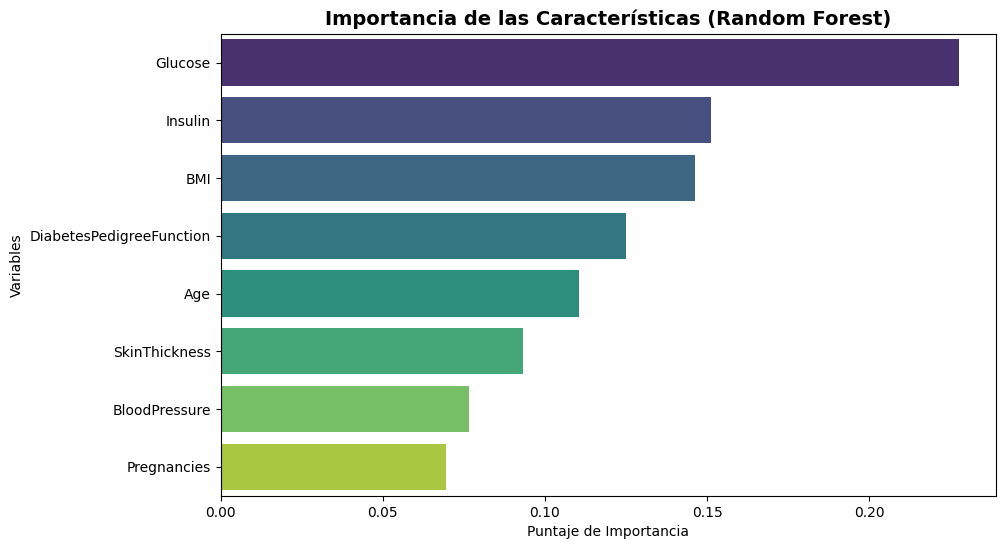

Ranking de variables:
             Característica  Importancia
1                   Glucose     0.227510
4                   Insulin     0.151249
5                       BMI     0.146390
6  DiabetesPedigreeFunction     0.125123
7                       Age     0.110360
3             SkinThickness     0.093081
2             BloodPressure     0.076656
0               Pregnancies     0.069631


In [21]:
# 1. Instanciar el modelo
# Usamos random_state para que los resultados sean siempre los mismos
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar con los datos escalados (X_train_final)
rf_model.fit(X_train_final, y_train)

# 3. Extraer las importancias
importancias = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Característica': X_train_final.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 4. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Característica', data=feature_importance_df, palette='viridis')
plt.title('Importancia de las Características (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Puntaje de Importancia')
plt.ylabel('Variables')
plt.show()

# 5. Mostrar el ranking por texto
print("Ranking de variables:")
print(feature_importance_df)

Hasta este punto se conservó insulin por su probabilidad de brindar información pero debido a que una graan parte de sus datos fueron imputados y que fue tomada como carcteristica muy importante, se decide prescindir de la columna.

In [22]:
# 1. Creamos una lista de columnas excluyendo la conflictiva
features_sin_insulina = [col for col in X_train_final.columns if col != 'Insulin']

# 2. Entrenamos un nuevo Random Forest solo con las columnas "fiables"
rf_check = RandomForestClassifier(n_estimators=100, random_state=42)
rf_check.fit(X_train_final[features_sin_insulina], y_train)

# 3. Ver el nuevo ranking
importancias_check = pd.DataFrame({
    'Característica': features_sin_insulina,
    'Importancia': rf_check.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("Nuevo Ranking (Sin Insulin):")
print(importancias_check)

Nuevo Ranking (Sin Insulin):
             Característica  Importancia
1                   Glucose     0.279968
4                       BMI     0.154024
5  DiabetesPedigreeFunction     0.141477
3             SkinThickness     0.130017
6                       Age     0.122405
2             BloodPressure     0.086865
0               Pregnancies     0.085244


# 10. Machine Learning

In [23]:
# Eliminamos la columna Insulin de los sets finales
X_train_final = X_train_final.drop(columns=['Insulin'])
X_test_final = X_test_final.drop(columns=['Insulin'])

In [24]:
# 1. Definimos las mejores variables según tu último ranking (sin Insulin)
# Basado en tu análisis previo: Glucose, BMI, DiabetesPedigreeFunction, SkinThickness, Age
top_features = ["Glucose", "BMI", "DiabetesPedigreeFunction", "SkinThickness", "Age"]

# 2. Filtramos los datasets
X_train_sel = X_train_final[top_features]
X_test_sel = X_test_final[top_features]

# 3. Entrenamos el modelo Random Forest
# Usamos n_estimators=100 (100 árboles) y random_state para consistencia
model = RandomForestClassifier(n_estimators=100, random_state=123)
model.fit(X_train_sel, y_train)

# 4. Predicción y Evaluación
y_pred = model.predict(X_test_sel)
accuracy = accuracy_score(y_test, y_pred)

print(f"Mejor Dataset: X_train_selected (Sin Insulin)")
print(f"Accuracy Score: {round(accuracy, 4)}")
print("-" * 30)
print("Informe de Clasificación:")
print(classification_report(y_test, y_pred))

Mejor Dataset: X_train_selected (Sin Insulin)
Accuracy Score: 0.7143
------------------------------
Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.75      0.82      0.79        94
           1       0.62      0.53      0.57        53

    accuracy                           0.71       147
   macro avg       0.69      0.67      0.68       147
weighted avg       0.71      0.71      0.71       147



Clase 0 (No Diabetes): El modelo es muy bueno detectando a personas sanas, con un Recall de 0.82.

Clase 1 (Diabetes): Aquí está el reto. El Recall es de 0.53, lo que significa que el modelo identifica correctamente al 53% de las personas que realmente tienen diabetes.

Precisión de Clase 1 (0.62): Cuando el modelo dice que alguien tiene diabetes, acierta el 62% de las veces.

## 10.1 Optimización

In [25]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Configuramos la búsqueda
grid_search = GridSearchCV(RandomForestClassifier(random_state=123), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_sel, y_train)

print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor Accuracy en validación: {round(grid_search.best_score_, 4)}")

Mejores parámetros encontrados: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Mejor Accuracy en validación: 0.7918


## 10.2 Entrenamiento del Modelo Definitivo

In [26]:
# Configuramos el modelo con los mejores parámetros encontrados
best_rf_model = RandomForestClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=5,
    n_estimators=100,
    random_state=123
)

# Entrenamos con el set seleccionado
best_rf_model.fit(X_train_sel, y_train)

# Predicciones finales sobre el set de test
y_pred_final = best_rf_model.predict(X_test_sel)

print(f"Modelo final entrenado y listo.")
print(f"Accuracy en Test: {round(accuracy_score(y_test, y_pred_final), 4)}")

Modelo final entrenado y listo.
Accuracy en Test: 0.7143


## 10.3 Evaluación Médica: Matriz de Confusión

<Figure size 800x600 with 0 Axes>

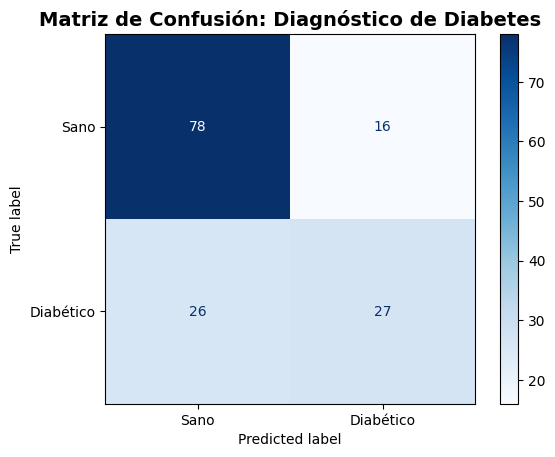

Informe Final de Clasificación:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79        94
           1       0.63      0.51      0.56        53

    accuracy                           0.71       147
   macro avg       0.69      0.67      0.68       147
weighted avg       0.71      0.71      0.71       147



In [27]:
# Crear la matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)

# Graficar de forma profesional
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano', 'Diabético'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión: Diagnóstico de Diabetes', fontsize=14, fontweight='bold')
plt.show()

# Informe detallado
print("Informe Final de Clasificación:")
print(classification_report(y_test, y_pred_final))

# Apartado, modelos gráficos para visualización

In [28]:
# 1. Entrenamos el árbol (usando los datos seleccionados)
tree_model = DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=123)
tree_model.fit(X_train_sel, y_train)

# 2. Generamos las reglas sin límite de caracteres
# El parámetro max_depth=None aquí asegura que export_text no corte niveles
tree_rules = export_text(tree_model, feature_names=list(X_train_sel.columns), max_depth=100)

# Guardar en un archivo 
with open("arbol_completo.txt", "w") as f:
    f.write(tree_rules)

# Imprimir en pantalla asegurando que no se trunque
print(tree_rules)

print("\n--- PROCESO FINALIZADO ---")
print("Si en la pantalla sale cortado, abre el archivo 'arbol_completo.txt' que se ha creado en tu carpeta.")




|--- Glucose <= 0.19
|   |--- Age <= -0.40
|   |   |--- SkinThickness <= -0.14
|   |   |   |--- BMI <= 0.72
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.58
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- DiabetesPedigreeFunction >  0.58
|   |   |   |   |   |--- BMI <= -1.29
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- BMI >  -1.29
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- BMI >  0.72
|   |   |   |   |--- class: 0
|   |   |--- SkinThickness >  -0.14
|   |   |   |--- DiabetesPedigreeFunction <= -1.05
|   |   |   |   |--- class: 1
|   |   |   |--- DiabetesPedigreeFunction >  -1.05
|   |   |   |   |--- SkinThickness <= -0.10
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- SkinThickness >  -0.10
|   |   |   |   |   |--- BMI <= 0.89
|   |   |   |   |   |   |--- DiabetesPedigreeFunction <= 0.07
|   |   |   |   |   |   |   |--- Glucose <= -0.33
|   |   |   |   |   |   |   |   |--- Glucose <= -1.33
|   |   |   |   |   |   |   |   |   |--- Age <

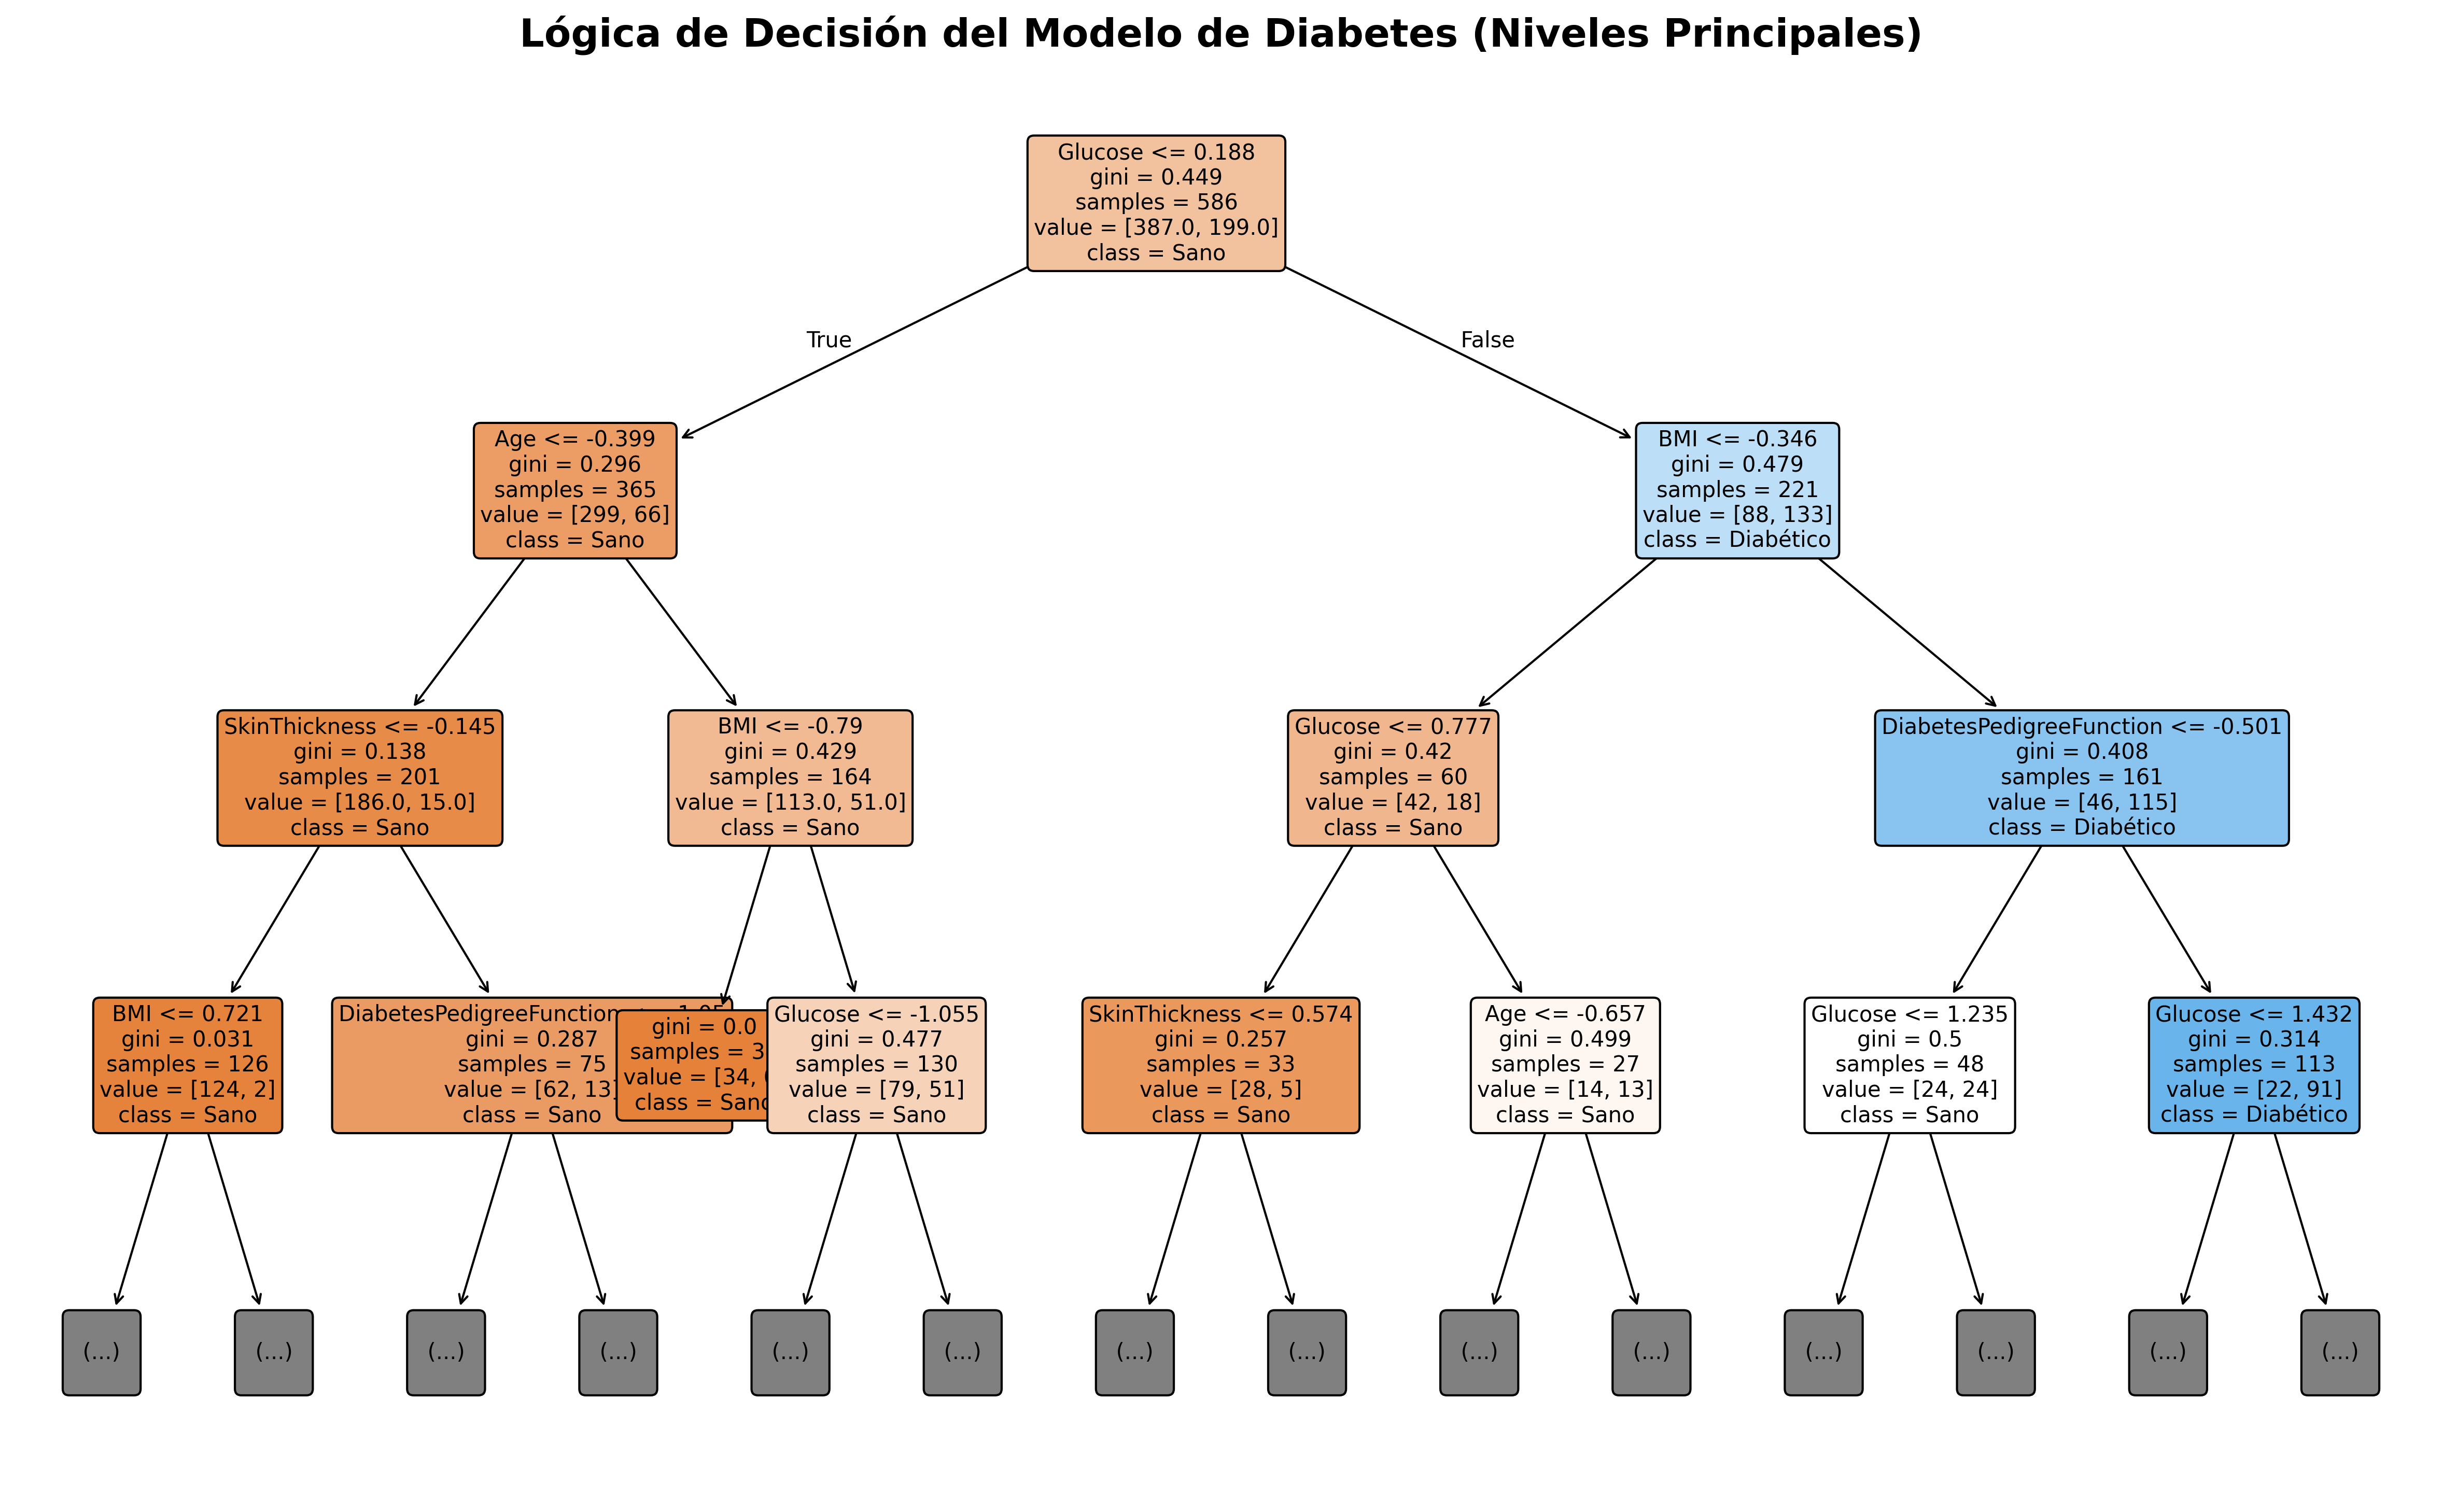

In [29]:
# 1. Definimos el tamaño de la figura (grande para que sea legible)
plt.figure(figsize=(20, 12), dpi=300)

# 2. Creamos el diagrama del árbol
# Usamos max_depth=3 para que la imagen no sea un caos de ramas pequeñas
# y podamos entender las decisiones principales.
plot_tree(
    tree_model, 
    feature_names = list(X_train_sel.columns), 
    class_names = ['Sano', 'Diabético'], # Etiquetas para clase 0 y 1
    filled = True,          # Colorea los nodos según la clase
    rounded = True,         # Bordes redondeados para estética
    fontsize = 10,          # Tamaño de letra legible
    max_depth = 3           # Limitamos la vista a los niveles más importantes
)

# 3. Añadimos un título y mostramos
plt.title("Lógica de Decisión del Modelo de Diabetes (Niveles Principales)", fontsize=18, fontweight='bold')
plt.show()

# 11 Guardar modelo

In [ ]:
# Guardamos el modelo entrenado
os.makedirs('../models/', exist_ok=True)
dump(best_rf_model, open('../models/random_forest_diabetes_v1.sav', 'wb'))

print("Modelo guardado exitosamente en ../models/")

In [31]:
# Guardamos los datos procesados

# Definimos la ruta que me proporcionaste
processed_path = "/workspaces/steven10015-intro-ml/data/processed"

# Guardamos los conjuntos (asumiendo que tus variables se llaman X_train, X_test, y_train, y_test)
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_data.to_csv(f"{processed_path}/clean_train.csv", index=False)
test_data.to_csv(f"{processed_path}/clean_test.csv", index=False)

print(f"Archivos guardados en: {processed_path}")

Archivos guardados en: /workspaces/steven10015-intro-ml/data/processed
